# Model A - Shared Encoder

차선, 정지선, 횡단보도 등 도로 구조 요소의 공통 시각 특징을 추출하는 Encoder.

- Backbone: ConvNeXt-Tiny
- Segmentation Head와 Vector Head가 공유
- PyTorch 기반 구현

## 1. Environment Check

In [1]:
import sys
import torch

print("Python version :", sys.version.split()[0])
print("Python path    :", sys.executable)

print("PyTorch version:", torch.__version__)
print("CUDA build     :", torch.version.cuda)
print("CUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))

Python version : 3.11.9
Python path    : c:\accident_ai\Accident_AI\.venv\Scripts\python.exe
PyTorch version: 2.13.0+cu126
CUDA build     : 12.6
CUDA available : True
GPU name       : NVIDIA GeForce RTX 3060


## 2. Path Setup

In [8]:
from pathlib import Path


# ============================================================
# 전체 로컬 작업공간
# ============================================================

WORKSPACE_ROOT = Path(r"C:\accident_ai")


# ============================================================
# 원본 이미지
# ============================================================

IMAGE_ROOT = (
    WORKSPACE_ROOT
    / "lane_data"
    / "Training"
    / "image"
)


# ============================================================
# 이전 Data Quality Check Notebook의 최종 출력
# = Model A Encoder 입력
# ============================================================

ENCODER_INPUT_ROOT = (
    WORKSPACE_ROOT
    / "outputs"
    / "modelA_Data_Quality_check_outputs"
)


IMAGE_MANIFEST_PATH = (
    ENCODER_INPUT_ROOT
    / "modelA_image_manifest_final.jsonl"
)

LANE_VECTOR_ORDERED_PATH = (
    ENCODER_INPUT_ROOT
    / "modelA_lane_vector_ordered_final.jsonl"
)


# ============================================================
# 필수 경로 존재 여부 확인
# ============================================================

for path_name, path in {
    "IMAGE_ROOT": IMAGE_ROOT,
    "IMAGE_MANIFEST_PATH": IMAGE_MANIFEST_PATH,
    "LANE_VECTOR_ORDERED_PATH": LANE_VECTOR_ORDERED_PATH,
}.items():

    if not path.exists():
        raise FileNotFoundError(
            f"{path_name} 경로가 없습니다: {path}"
        )


print("IMAGE_ROOT:")
print(IMAGE_ROOT)

print()

print("ENCODER_INPUT_ROOT:")
print(ENCODER_INPUT_ROOT)

print()

print("IMAGE_MANIFEST_PATH:")
print(IMAGE_MANIFEST_PATH)

print()

print("LANE_VECTOR_ORDERED_PATH:")
print(LANE_VECTOR_ORDERED_PATH)

IMAGE_ROOT:
C:\accident_ai\lane_data\Training\image

ENCODER_INPUT_ROOT:
C:\accident_ai\outputs\modelA_Data_Quality_check_outputs

IMAGE_MANIFEST_PATH:
C:\accident_ai\outputs\modelA_Data_Quality_check_outputs\modelA_image_manifest_final.jsonl

LANE_VECTOR_ORDERED_PATH:
C:\accident_ai\outputs\modelA_Data_Quality_check_outputs\modelA_lane_vector_ordered_final.jsonl


## 3. Load Final Quality-Checked Data

In [11]:
import pandas as pd


# ============================================================
# Final Image Manifest Load
# ============================================================

df_image_manifest = pd.read_json(
    IMAGE_MANIFEST_PATH,
    lines=True
)


# ============================================================
# Final Ordered Lane Vector Load
# ============================================================

df_lane_vector_ordered = pd.read_json(
    LANE_VECTOR_ORDERED_PATH,
    lines=True
)


# ============================================================
# 기본 구조 확인
# ============================================================

print("Final Image Manifest shape:")
print(df_image_manifest.shape)

print(
    "Final Image Manifest 고유 이미지:",
    df_image_manifest["file_name"].nunique()
)

print()

print("Final Ordered Lane Vector shape:")
print(df_lane_vector_ordered.shape)

print(
    "Final Ordered Lane Vector 고유 이미지:",
    df_lane_vector_ordered["file_name"].nunique()
)

print()

print("[Final Image Manifest sample]")
display(df_image_manifest.head(10))

print()

print("[Final Ordered Lane Vector sample]")
display(df_lane_vector_ordered.head(10))

Final Image Manifest shape:
(8788, 11)
Final Image Manifest 고유 이미지: 8788

Final Ordered Lane Vector shape:
(46539, 14)
Final Ordered Lane Vector 고유 이미지: 8763

[Final Image Manifest sample]


,file_name,image_size,annotation_count,traffic_lane_count,stop_line_count,crosswalk_count,has_traffic_lane,has_stop_line,has_crosswalk,annotation_type,blackbox_id
0,13883084.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
1,13883085.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
2,13883471.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
3,13883472.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
4,13883473.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
5,13883474.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
6,13883475.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
7,13883476.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
8,13883477.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
9,13883478.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0



[Final Ordered Lane Vector sample]


,file_name,image_size,lane_id,lane_order,lane_color,lane_type,category,x_data,y_data,point_count,lane_order_x,lane_order_y,lane_order_method,blackbox_id
0,13883084.jpg,"[1080, 1920]",0,0,white,solid,polyline,"[207, 206, 480, 832]","[724, 723, 663, 584]",4,604.759494,635,common_y,0
1,13883084.jpg,"[1080, 1920]",1,1,white,dotted,polyline,"[909, 809]","[591, 651]",2,835.666667,635,common_y,0
2,13883084.jpg,"[1080, 1920]",7,2,white,solid,polyline,"[1022, 1145, 1263]","[589, 684, 778]",3,1081.557895,635,common_y,0
3,13883084.jpg,"[1080, 1920]",6,3,white,solid,polyline,"[1021, 1129, 1311]","[582, 653, 772]",3,1101.619718,635,common_y,0
4,13883084.jpg,"[1080, 1920]",5,4,white,solid,polyline,"[1678, 1274, 1035]","[739, 630, 568]",3,1292.532110,635,common_y,0
5,13883084.jpg,"[1080, 1920]",4,5,white,solid,polyline,"[1031, 1270, 1560, 1709]","[565, 623, 696, 731]",4,1317.671233,635,common_y,0
6,13883084.jpg,"[1080, 1920]",2,6,white,dotted,polyline,"[1162, 1561]","[578, 635]",2,1561.000000,635,common_y,0
7,13883084.jpg,"[1080, 1920]",3,7,white,solid,polyline,"[1194, 1547, 1853, 1908]","[571, 607, 640, 649]",4,1806.636364,635,common_y,0
8,13883085.jpg,"[1080, 1920]",0,0,white,solid,polyline,"[265, 499, 842]","[716, 658, 584]",3,531.445946,651,common_y,0
9,13883085.jpg,"[1080, 1920]",1,1,white,dotted,polyline,"[905, 703]","[600, 723]",2,821.243902,651,common_y,0


## 4. Encoder Input Image Check

In [12]:
# ============================================================
# 실제 이미지 경로 구성
# ============================================================

image_paths = list(
    IMAGE_ROOT.rglob("*.jpg")
)


image_path_map = {
    path.name: path
    for path in image_paths
}


print("실제 JPG 파일 수:", len(image_paths))
print("고유 JPG file_name 수:", len(image_path_map))


# 동일한 file_name이 서로 다른 폴더에 중복되어 있지 않은지 확인
assert (
    len(image_paths)
    ==
    len(image_path_map)
), (
    "서로 다른 이미지 폴더에 동일한 file_name이 존재합니다."
)


# ============================================================
# Final Manifest 이미지가 실제로 모두 존재하는지 확인
# ============================================================

manifest_file_names = set(
    df_image_manifest["file_name"]
)

actual_file_names = set(
    image_path_map.keys()
)


missing_image_files = (
    manifest_file_names
    - actual_file_names
)


print(
    "Final Manifest 이미지 수:",
    len(manifest_file_names)
)

print(
    "실제 이미지에서 찾지 못한 수:",
    len(missing_image_files)
)


assert (
    len(missing_image_files)
    ==
    0
), (
    f"Final Manifest 이미지 중 실제 JPG를 찾지 못했습니다: "
    f"{list(missing_image_files)[:10]}"
)


print()
print("Encoder 입력 이미지 경로 연결 완료!")

실제 JPG 파일 수: 15000
고유 JPG file_name 수: 15000
Final Manifest 이미지 수: 8788
실제 이미지에서 찾지 못한 수: 0

Encoder 입력 이미지 경로 연결 완료!


file_name : 13883084.jpg
image path:
C:\accident_ai\lane_data\Training\image\image_1920_1080_daylight_09\13883084.jpg

PIL image mode: RGB
PIL image size: (1920, 1080)
Manifest size : [1080, 1920]


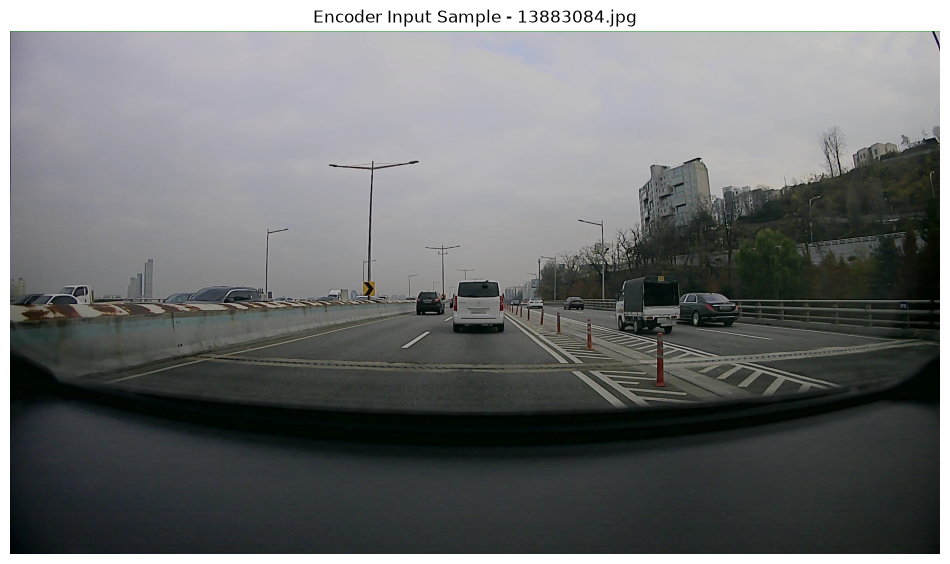

In [13]:
from PIL import Image
import matplotlib.pyplot as plt


# ============================================================
# Final Manifest 첫 번째 이미지 확인
# ============================================================

sample_row = df_image_manifest.iloc[0]

sample_file_name = sample_row["file_name"]
sample_image_path = image_path_map[sample_file_name]

sample_image = Image.open(
    sample_image_path
).convert("RGB")


print("file_name :", sample_file_name)

print("image path:")
print(sample_image_path)

print()

print("PIL image mode:", sample_image.mode)
print("PIL image size:", sample_image.size)
print("Manifest size :", sample_row["image_size"])


plt.figure(figsize=(12, 7))

plt.imshow(sample_image)

plt.title(
    f"Encoder Input Sample - {sample_file_name}"
)

plt.axis("off")

plt.show()